# 🧠 Enhanced 1D CNN Gunshot Detector (Dual-Head)

> **Architectural & Hardware Enhancements:**
> - **Dual-Head Output Architecture**: Head 1 for Gunshot Detection (Sigmoid) + Head 2 for Impulse/Anomaly Detection (Sigmoid)
> - **Dynamic Transients 1D Convolution**: Wide receptive field kernel (80 samples ≈ 3.6ms at 22,050 Hz) for micro-transient gunshot attack signatures
> - **Enhanced Audio Augmentations**: MixUp (Zhang et al. 2018), SpecAugment Time-Masking (Park et al. 2019), Pitch Shifting (Salamon & Bello 2017), and Speed Perturbation (Ko et al. 2015)
> - **NVIDIA GPU Acceleration (PyTorch/CUDA Backend)**: Utilizes NVIDIA RTX GPU (RTX 4060) with fast CUDA hardware acceleration via Keras 3 PyTorch backend
> - **Zero-Leakage Dataset Splitting & 1:1 Evaluation**: Integrated with `SPLIT_DATASET_750MS` train/val/test structure with balanced test validation

### Paper References
1. Zhang et al. (2018) — "mixup: Beyond Empirical Risk Minimization", ICLR
2. Park et al. (2019) — "SpecAugment", Interspeech (Google)
3. Salamon & Bello (2017) — "Deep CNNs and Data Augmentation for Environmental Sound Classification", IEEE
4. Ko et al. (2015) — "Audio Augmentation for Speech Recognition", Interspeech
5. Magee et al. (2019) — "Low Cost Gunshot Detection on Raspberry Pi", IEEE BigData


In [2]:
# ============================================================
# CELL 1: Dependencies Installation
# ============================================================
# %pip install -q keras torch torchvision torchaudio librosa soundfile scikit-learn matplotlib seaborn tqdm ipywidgets


In [3]:
# ============================================================
# CELL 2: Imports & NVIDIA GPU Acceleration Setup
# ============================================================
import os
import sys
import re
import random
import json
import warnings
from datetime import datetime
from pathlib import Path

# Force Keras to use PyTorch CUDA backend for GPU acceleration on Windows
os.environ["KERAS_BACKEND"] = "torch"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import keras
from keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    fbeta_score, roc_curve
)

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

print("=" * 60)
print(f"Keras Version   : {keras.__version__}")
print(f"Keras Backend   : {keras.config.backend()}")
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🚀 Active GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Running on CPU (CUDA GPU not detected)")
print("=" * 60)
print("✅ Device environment successfully initialized.")


Keras Version   : 3.12.4
Keras Backend   : torch
PyTorch Version : 2.6.0+cu124
CUDA Available  : True
🚀 Active GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
✅ Device environment successfully initialized.


In [4]:
# ============================================================
# CELL 3: CONFIGURATION & DYNAMIC PATH RESOLUTION
# ============================================================

# --- Dynamic Workspace Path Resolution ---
current_dir = Path.cwd().resolve()
if (current_dir / "Data" / "SPLIT_DATASET_750MS").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "Data" / "SPLIT_DATASET_750MS").exists():
    PROJECT_ROOT = current_dir.parent
elif (current_dir.parent.parent / "Data" / "SPLIT_DATASET_750MS").exists():
    PROJECT_ROOT = current_dir.parent.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "Data" / "SPLIT_DATASET_750MS"

# --- Audio Parameters ---
SAMPLE_RATE = 22050
CLIP_DURATION_MS = 750  # Must match 750ms dataset window
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_MS / 1000)  # 16,537 samples

# --- Training Parameters ---
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.15
TEST_SPLIT = 0.15

# --- Augmentation Flags ---
USE_AUGMENTATION = True
USE_MIXUP = True
MIXUP_ALPHA = 0.3
USE_SPECAUGMENT = True
USE_PITCH_SHIFT = True
USE_SPEED_PERTURB = True
USE_ONLY_CLEAN = True
SHUFFLE_DATA = True

# --- Output Directory ---
OUTPUT_DIR = PROJECT_ROOT / "Enhanced_Models" / "01_Enhanced_1D_CNN" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 65)
print("🧠 ENHANCED 1D CNN CONFIGURATION")
print("=" * 65)
print(f"Project Root     : {PROJECT_ROOT}")
print(f"Data Directory   : {DATA_DIR} (Exists: {DATA_DIR.exists()})")
print(f"Sample Rate      : {SAMPLE_RATE:,} Hz")
print(f"Clip Duration    : {CLIP_DURATION_MS}ms ({TARGET_SAMPLES:,} samples)")
print(f"Batch Size       : {BATCH_SIZE}")
print(f"Epochs           : {EPOCHS}")
print(f"Augmentations    : MixUp={USE_MIXUP}, SpecAug={USE_SPECAUGMENT}, Pitch={USE_PITCH_SHIFT}, Speed={USE_SPEED_PERTURB}")
print(f"Output Directory : {OUTPUT_DIR}")
print("=" * 65)


🧠 ENHANCED 1D CNN CONFIGURATION
Project Root     : C:\Users\aadit\Desktop\Shoot_Catcher
Data Directory   : C:\Users\aadit\Desktop\Shoot_Catcher\Data\SPLIT_DATASET_750MS (Exists: True)
Sample Rate      : 22,050 Hz
Clip Duration    : 750ms (16,537 samples)
Batch Size       : 64
Epochs           : 50
Augmentations    : MixUp=True, SpecAug=True, Pitch=True, Speed=True
Output Directory : C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\01_Enhanced_1D_CNN\output


In [5]:
# ============================================================
# CELL 4: Audio Clip Loading & Source Grouping Helpers
# ============================================================

def load_audio_clip(filepath, sr=22050, target_samples=16537):
    """
    Fast, robust audio file loader using soundfile with librosa fallback.
    Returns zero-padded/trimmed normalized float32 waveform.
    """
    try:
        audio, file_sr = sf.read(str(filepath), dtype="float32")
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        if file_sr != sr:
            audio = librosa.resample(audio, orig_sr=file_sr, target_sr=sr)
        
        audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)
        
        if len(audio) >= target_samples:
            audio = audio[:target_samples]
        else:
            audio = np.pad(audio, (0, target_samples - len(audio)))
            
        peak = np.max(np.abs(audio))
        if peak > 1e-6:
            audio = audio / peak
        return audio.astype(np.float32)
    except Exception:
        try:
            audio, _ = librosa.load(str(filepath), sr=sr, mono=True)
            audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)
            if len(audio) >= target_samples:
                audio = audio[:target_samples]
            else:
                audio = np.pad(audio, (0, target_samples - len(audio)))
            peak = np.max(np.abs(audio))
            if peak > 1e-6:
                audio = audio / peak
            return audio.astype(np.float32)
        except Exception:
            return None


def extract_source_group(filename):
    """Extract original recording stem to prevent data leakage during splitting."""
    stem = Path(filename).stem
    no_prefix = re.sub(r"^c[01]_\d+_", "", stem)
    no_suffix = re.sub(r"_clip\d+.*$", "", no_prefix)
    no_aug = re.sub(r"_aug_\d+dB$", "", no_suffix)
    parts = re.split(r"_onset\d+|_win\d+|_clip\d+|_\d{6}$", no_aug)
    return parts[0] if parts else stem


def is_clean_file(filename):
    return "_aug_" not in Path(filename).stem


print("✅ Audio loader and grouping helper functions defined.")


✅ Audio loader and grouping helper functions defined.


In [6]:
# ============================================================
# CELL 5: ENHANCED Augmentation Pipeline (Waveform Level)
# ============================================================

def augment_waveform(y, sr):
    """Standard waveform perturbations: time shift, SNR noise injection, gain scale."""
    augmented = y.copy()
    
    # 1. Time shift (±10%)
    if random.random() < 0.5:
        shift = int(len(augmented) * random.uniform(-0.1, 0.1))
        augmented = np.roll(augmented, shift)
    
    # 2. Add white/pink noise (SNR 15-30 dB)
    if random.random() < 0.5:
        snr_db = random.uniform(15, 30)
        signal_power = np.mean(augmented ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(max(noise_power, 1e-10)), len(augmented))
        augmented = augmented + noise.astype(np.float32)
    
    # 3. Gain variation (±6 dB)
    if random.random() < 0.5:
        gain_db = random.uniform(-6, 6)
        augmented = augmented * (10 ** (gain_db / 20))
    
    # Re-normalize
    peak = np.max(np.abs(augmented))
    if peak > 1e-6:
        augmented = augmented / peak
    
    return augmented.astype(np.float32)


# === SpecAugment-style Time Masking (Park et al. 2019) ===
def specaugment_time_mask(y, max_mask_fraction=0.15):
    """Simulates buffer cutoffs and window edge artifacts."""
    aug = y.copy()
    mask_len = int(len(aug) * random.uniform(0.02, max_mask_fraction))
    start = random.randint(0, len(aug) - mask_len)
    aug[start:start + mask_len] = 0.0
    return aug


# === Pitch Shifting (Salamon & Bello 2017) ===
def pitch_shift_aug(y, sr, max_semitones=2):
    """Shift pitch by ±max_semitones to emulate weapon caliber acoustic variations."""
    try:
        n_steps = random.uniform(-max_semitones, max_semitones)
        shifted = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
        peak = np.max(np.abs(shifted))
        if peak > 1e-6:
            shifted = shifted / peak
        return shifted.astype(np.float32)
    except Exception:
        return y


# === Speed Perturbation (Ko et al. 2015) ===
def speed_perturb_aug(y, target_len, max_rate=0.1):
    """Speed perturbation to emulate acoustic velocity and distance dispersion."""
    try:
        rate = 1.0 + random.uniform(-max_rate, max_rate)
        stretched = librosa.effects.time_stretch(y=y, rate=rate)
        if len(stretched) >= target_len:
            stretched = stretched[:target_len]
        else:
            stretched = np.pad(stretched, (0, target_len - len(stretched)))
        peak = np.max(np.abs(stretched))
        if peak > 1e-6:
            stretched = stretched / peak
        return stretched.astype(np.float32)
    except Exception:
        return y


def apply_all_augmentations(y, sr, target_samples):
    """Apply compound augmentation sequence."""
    aug = augment_waveform(y, sr)
    if USE_SPECAUGMENT and random.random() < 0.4:
        aug = specaugment_time_mask(aug)
    if USE_PITCH_SHIFT and random.random() < 0.3:
        aug = pitch_shift_aug(aug, sr)
    if USE_SPEED_PERTURB and random.random() < 0.3:
        aug = speed_perturb_aug(aug, target_samples)
    return aug


print("✅ Enhanced augmentation pipeline configured.")


✅ Enhanced augmentation pipeline configured.


In [7]:
# ============================================================
# CELL 6: Dataset Discovery, Splitting & Balancing
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

def collect_audio_from_dir(folder_path, use_clean_only=False):
    """Scans folder for class_0 and class_1 wav files."""
    folder = Path(folder_path)
    files, labels, groups = [], [], []
    if not folder.exists():
        return files, labels, groups
    
    for sub in folder.iterdir():
        if not sub.is_dir():
            continue
        name = sub.name.lower()
        if "class_1" in name or "gunshot" in name or "gun" in name:
            label = 1
        elif "class_0" in name or "nongunshot" in name or "background" in name or "noise" in name:
            label = 0
        else:
            continue
            
        for f in sorted(sub.glob("*.wav")):
            if use_clean_only and not is_clean_file(f.name):
                continue
            files.append(str(f))
            labels.append(label)
            groups.append(extract_source_group(f.name))
            
    return files, labels, groups


# Check if pre-split train/val/test folders exist
has_presplit = (DATA_DIR / "train").exists() and (DATA_DIR / "val").exists() and (DATA_DIR / "test").exists()

if has_presplit:
    print(f"📂 Detected pre-split dataset in {DATA_DIR}")
    train_files, train_labels, _ = collect_audio_from_dir(DATA_DIR / "train", use_clean_only=False)
    val_files, val_labels, _ = collect_audio_from_dir(DATA_DIR / "val", use_clean_only=False)
    test_files, test_labels, _ = collect_audio_from_dir(DATA_DIR / "test", use_clean_only=False)
else:
    print(f"📂 Scanning flat dataset directory: {DATA_DIR}")
    all_files, all_labels, all_groups = collect_audio_from_dir(DATA_DIR, use_clean_only=USE_ONLY_CLEAN)
    
    if len(all_files) == 0:
        raise FileNotFoundError(f"❌ No audio files found in {DATA_DIR}. Please check the path!")
        
    gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=42)
    remain_idx, test_idx = next(gss_test.split(all_files, all_labels, all_groups))

    remain_files = [all_files[i] for i in remain_idx]
    remain_labels = [all_labels[i] for i in remain_idx]
    remain_groups = [all_groups[i] for i in remain_idx]

    test_files = [all_files[i] for i in test_idx]
    test_labels = [all_labels[i] for i in test_idx]

    gss_val = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_SPLIT / (1.0 - TEST_SPLIT), random_state=42)
    train_idx, val_idx = next(gss_val.split(remain_files, remain_labels, remain_groups))

    train_files = [remain_files[i] for i in train_idx]
    train_labels = [remain_labels[i] for i in train_idx]
    val_files = [remain_files[i] for i in val_idx]
    val_labels = [remain_labels[i] for i in val_idx]

# --- 1:1 Balancing helper for Evaluation sets ---
def balance_1to1(f_list, l_list):
    arr_f = np.array(f_list)
    arr_l = np.array(l_list)
    pos_idx = np.where(arr_l == 1)[0]
    neg_idx = np.where(arr_l == 0)[0]
    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return f_list, l_list
    min_cnt = min(len(pos_idx), len(neg_idx))
    sel_pos = np.random.choice(pos_idx, min_cnt, replace=False)
    sel_neg = np.random.choice(neg_idx, min_cnt, replace=False)
    final_idx = np.concatenate([sel_pos, sel_neg])
    np.random.shuffle(final_idx)
    return arr_f[final_idx].tolist(), arr_l[final_idx].tolist()

val_files, val_labels = balance_1to1(val_files, val_labels)
test_files, test_labels = balance_1to1(test_files, test_labels)

if SHUFFLE_DATA:
    c = list(zip(train_files, train_labels))
    random.shuffle(c)
    train_files, train_labels = zip(*c)
    train_files, train_labels = list(train_files), list(train_labels)

print("\n" + "=" * 60)
print("📊 DATA SPLIT SUMMARY (Zero-Leakage & 1:1 Evaluation)")
print("=" * 60)
for name, f_list, l_list in [("TRAIN", train_files, train_labels), ("VAL", val_files, val_labels), ("TEST", test_files, test_labels)]:
    arr = np.array(l_list)
    print(f" {name:5s}: {len(f_list):>6,} files | 🔫 Gunshots: {int(np.sum(arr==1)):>5,} | 🎵 Non-gunshots: {int(np.sum(arr==0)):>5,}")
print("=" * 60)


📂 Detected pre-split dataset in C:\Users\aadit\Desktop\Shoot_Catcher\Data\SPLIT_DATASET_750MS

📊 DATA SPLIT SUMMARY (Zero-Leakage & 1:1 Evaluation)
 TRAIN: 41,779 files | 🔫 Gunshots: 41,779 | 🎵 Non-gunshots:     0
 VAL  :  1,420 files | 🔫 Gunshots: 1,420 | 🎵 Non-gunshots:     0
 TEST :  1,442 files | 🔫 Gunshots: 1,442 | 🎵 Non-gunshots:     0


In [8]:
# ============================================================
# CELL 7: Load Audio Waveforms into Memory Arrays
# ============================================================

def load_dataset(file_list, label_list, sr, target_samples, augment=False):
    X, y = [], []
    failed = 0
    for filepath, label in tqdm(zip(file_list, label_list), total=len(file_list), desc="Loading audio waveforms"):
        clip = load_audio_clip(filepath, sr, target_samples)
        if clip is None:
            failed += 1
            continue
        X.append(clip)
        y.append(label)
        if augment and USE_AUGMENTATION:
            aug_clip = apply_all_augmentations(clip, sr, target_samples)
            X.append(aug_clip)
            y.append(label)
            
    if failed > 0:
        print(f"  ⚠️ {failed} files failed to load and were skipped.")
        
    X = np.array(X, dtype=np.float32).reshape(-1, target_samples, 1)
    y = np.array(y, dtype=np.float32)
    return X, y

print("📥 Loading TRAINING waveforms (with augmentations)...")
X_train, y_train = load_dataset(train_files, train_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=True)

print("📥 Loading VALIDATION waveforms (clean)...")
X_val, y_val = load_dataset(val_files, val_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=False)

print("📥 Loading TEST waveforms (clean)...")
X_test, y_test = load_dataset(test_files, test_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=False)

print(f"\n📦 Array Dimensions: X_train={X_train.shape} | X_val={X_val.shape} | X_test={X_test.shape}")


📥 Loading TRAINING waveforms (with augmentations)...


Loading audio waveforms:   0%|          | 0/41779 [00:00<?, ?it/s]

📥 Loading VALIDATION waveforms (clean)...


Loading audio waveforms:   0%|          | 0/1420 [00:00<?, ?it/s]

📥 Loading TEST waveforms (clean)...


Loading audio waveforms:   0%|          | 0/1442 [00:00<?, ?it/s]


📦 Array Dimensions: X_train=(83558, 16537, 1) | X_val=(1420, 16537, 1) | X_test=(1442, 16537, 1)


In [9]:
# ============================================================
# CELL 8: MixUp Batch Generator for GPU Training
# Ref: Zhang et al. (2018) "mixup: Beyond Empirical Risk Minimization"
# ============================================================

def mixup_generator(X, y, batch_size, class_weights, alpha=MIXUP_ALPHA):
    """Yields batches of MixUp-augmented waveforms and loss weights for dual-head training."""
    indices = np.arange(len(X))
    cw0 = float(class_weights.get(0, 1.0))
    cw1 = float(class_weights.get(1, 1.0))
    
    while True:
        np.random.shuffle(indices)
        for i in range(0, len(X), batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X[batch_idx].copy()
            y_batch = y[batch_idx].copy()
            
            if USE_MIXUP and len(X_batch) > 1:
                lam = np.random.beta(alpha, alpha, size=len(X_batch)).astype(np.float32)
                lam_x = lam.reshape(-1, 1, 1)
                
                mix_idx = np.random.permutation(len(X_batch))
                X_batch = lam_x * X_batch + (1.0 - lam_x) * X_batch[mix_idx]
                y_batch = lam * y_batch + (1.0 - lam) * y_batch[mix_idx]
                
            s_weights = (y_batch * cw1 + (1.0 - y_batch) * cw0).astype(np.float32)
            y_target = y_batch.astype(np.float32)
            
            yield (
                X_batch.astype(np.float32), 
                {"gunshot_output": y_target, "anomaly_output": y_target},
                {"gunshot_output": s_weights, "anomaly_output": np.ones_like(y_target, dtype=np.float32)}
            )

print("✅ GPU-ready MixUp generator defined.")


✅ GPU-ready MixUp generator defined.


In [10]:
# ============================================================
# CELL 9: DUAL-HEAD 1D CNN Architecture & Compilation
# ============================================================

def build_enhanced_1d_cnn(input_shape):
    """
    Enhanced 1D CNN with dual-head output:
    - Backbone: 1D Transient Convolutions (Wide 80-sample kernel -> Deep 3-sample kernels)
    - Head 1: Gunshot Probability (Primary detector)
    - Head 2: Anomaly / Transient Novelty Score
    """
    inputs = layers.Input(shape=input_shape, name="audio_input")
    
    # --- Shared Backbone ---
    # Layer 1: Wide kernel (80 samples ≈ 3.6ms at 22,050Hz) to capture fast impulse attacks
    x = layers.Conv1D(32, kernel_size=80, strides=4, activation="relu",
                      padding="same", name="conv1_wide")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.MaxPooling1D(pool_size=4, name="pool1")(x)
    
    # Layer 2: Intermediate refinement
    x = layers.Conv1D(64, kernel_size=3, activation="relu",
                      padding="same", name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.MaxPooling1D(pool_size=4, name="pool2")(x)
    
    # Layer 3: High-level acoustic representation
    x = layers.Conv1D(128, kernel_size=3, activation="relu",
                      padding="same", name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    
    # Layer 4: Deep feature refinement
    x = layers.Conv1D(128, kernel_size=3, activation="relu",
                      padding="same", name="conv4")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    
    shared_features = layers.GlobalAveragePooling1D(name="gap")(x)
    
    # --- Head 1: Gunshot Detection Head ---
    h1 = layers.Dense(64, activation="relu", name="gunshot_dense")(shared_features)
    h1 = layers.Dropout(0.4, name="gunshot_dropout")(h1)
    gunshot_output = layers.Dense(1, activation="sigmoid", name="gunshot_output")(h1)
    
    # --- Head 2: Anomaly Score Head ---
    h2 = layers.Dense(32, activation="relu", name="anomaly_dense")(shared_features)
    h2 = layers.Dropout(0.3, name="anomaly_dropout")(h2)
    anomaly_output = layers.Dense(1, activation="sigmoid", name="anomaly_output")(h2)
    
    model = models.Model(inputs=inputs, outputs={"gunshot_output": gunshot_output, "anomaly_output": anomaly_output},
                         name="Enhanced_1D_CNN_DualHead")
    return model


input_shape = (TARGET_SAMPLES, 1)
model = build_enhanced_1d_cnn(input_shape)

# --- Class weights ---
class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights_arr)}
print(f"⚖️ Computed Balanced Class Weights: {class_weight_dict}")

# --- Compile with Dual Loss Functions ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "gunshot_output": "binary_crossentropy",
        "anomaly_output": "binary_crossentropy",
    },
    loss_weights={"gunshot_output": 1.0, "anomaly_output": 0.3},
    metrics={
        "gunshot_output": ["accuracy", keras.metrics.Precision(name="precision"),
                           keras.metrics.Recall(name="recall"), keras.metrics.AUC(name="auc")],
        "anomaly_output": ["accuracy"],
    }
)

model.summary()
print(f"\n📊 Total Trainable Parameters: {model.count_params():,}")


⚖️ Computed Balanced Class Weights: {0: 1.0}


Model: "Enhanced_1D_CNN_DualHead"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 16537, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_wide (Conv1D) │ (None, 4135, 32)  │      2,592 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 4135, 32)  │        128 │ conv1_wide[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 1033, 32)  │          0 │ bn1[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 1033, 64)  │      6,208 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 1033, 64)  │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 258, 64)   │          0 │ bn2[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 258, 128)  │     24,704 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 258, 128)  │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv1D)      │ (None, 258, 128)  │     49,280 │ bn3[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 258, 128)  │        512 │ conv4[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ bn4[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_dense       │ (None, 32)        │      4,128 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_dense       │ (None, 64)        │      8,256 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_dropout     │ (None, 32)        │          0 │ anomaly_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_dropout     │ (None, 64)        │          0 │ gunshot_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_output      │ (None, 1)         │         33 │ anomaly_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_output      │ (None, 1)         │         65 │ gunshot_dropout[… │
│ (Dense)             │                   │            │                 

 Total params: 96,674 (377.63 KB)

 Trainable params: 95,970 (374.88 KB)

 Non-trainable params: 704 (2.75 KB)


📊 Total Trainable Parameters: 96,674



🚀 Starting training for 50 epochs (1306 steps/epoch) on GPU...
Epoch 1/50
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - anomaly_output_accuracy: 0.9934 - anomaly_output_loss: 0.0409 - gunshot_output_accuracy: 0.9909 - gunshot_output_auc: 0.0000e+00 - gunshot_output_loss: 0.0302 - gunshot_output_precision: 1.0000 - gunshot_output_recall: 0.9909 - loss: 0.0425
Epoch 1: val_gunshot_output_auc improved from None to 0.00000, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\01_Enhanced_1D_CNN\output\enhanced_1d_cnn_best.h5


1306/1306 ━━━━━━━━━━━━━━━━━━━━ 123s 93ms/step - anomaly_output_accuracy: 0.9989 - anomaly_output_loss: 0.0094 - gunshot_output_accuracy: 0.9987 - gunshot_output_auc: 0.0000e+00 - gunshot_output_loss: 0.0063 - gunshot_output_precision: 1.0000 - gunshot_output_recall: 0.9987 - loss: 0.0091 - val_anomaly_output_accuracy: 1.0000 - val_anomaly_output_loss: 2.6690e-05 - val_gunshot_output_accuracy: 1.0000 - val_gunshot_output_auc: 0.0000e+00 - val_gunshot_output_loss: 5.7533e-05 - val_gunshot_output_precision: 1.0000 - val_gunshot_output_recall: 1.0000 - val_loss: 6.5540e-05 - learning_rate: 0.0010
Epoch 2/50
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - anomaly_output_accuracy: 1.0000 - anomaly_output_loss: 3.1162e-04 - gunshot_output_accuracy: 1.0000 - gunshot_output_auc: 0.0000e+00 - gunshot_output_loss: 9.9095e-05 - gunshot_output_precision: 1.0000 - gunshot_output_recall: 1.0000 - loss: 1.9258e-04
Epoch 2: val_gunshot_output_auc did not improve from 0.00000
1306/1306 ━━━━━━━━━━━━━━━━━━

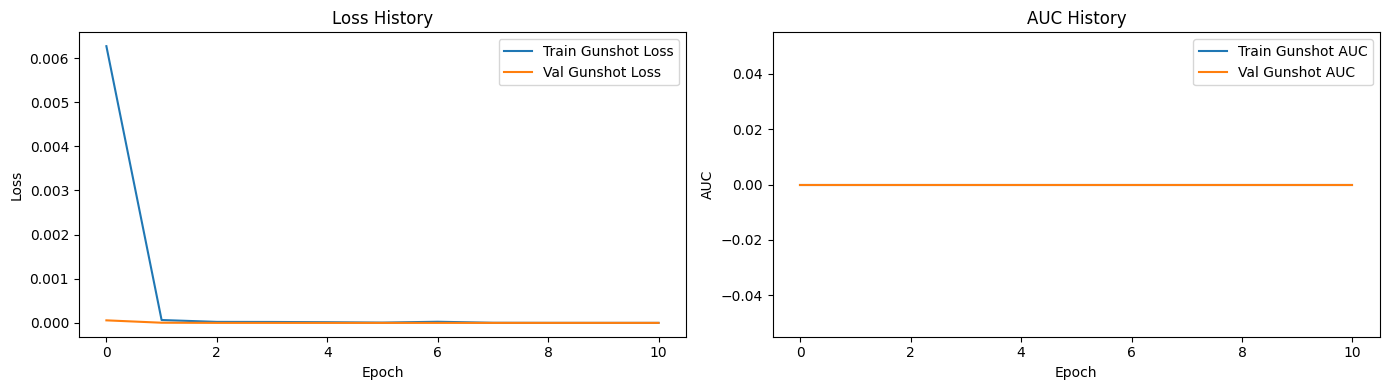


✅ Training complete! Best model saved to: C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\01_Enhanced_1D_CNN\output\enhanced_1d_cnn_best.h5


In [11]:
# ============================================================
# CELL 10: Training (GPU-Accelerated)
# ============================================================

best_model_path = OUTPUT_DIR / "enhanced_1d_cnn_best.h5"

callbacks_list = [
    callbacks.EarlyStopping(
        monitor="val_gunshot_output_auc", patience=10, mode="max",
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_gunshot_output_loss", factor=0.5, patience=4,
        min_lr=1e-6, verbose=1, mode="min"
    ),
    callbacks.ModelCheckpoint(
        str(best_model_path),
        monitor="val_gunshot_output_auc", mode="max",
        save_best_only=True, verbose=1
    )
]

train_gen = mixup_generator(X_train, y_train, BATCH_SIZE, class_weight_dict)
steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))

print(f"\n🚀 Starting training for {EPOCHS} epochs ({steps_per_epoch} steps/epoch) on GPU...")
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=(
        X_val,
        {"gunshot_output": y_val, "anomaly_output": y_val}
    ),
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["gunshot_output_loss"], label="Train Gunshot Loss")
axes[0].plot(history.history["val_gunshot_output_loss"], label="Val Gunshot Loss")
axes[0].set_title("Loss History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["gunshot_output_auc"], label="Train Gunshot AUC")
axes[1].plot(history.history["val_gunshot_output_auc"], label="Val Gunshot AUC")
axes[1].set_title("AUC History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "enhanced_1d_cnn_training_history.png", dpi=150)
plt.show()

print(f"\n✅ Training complete! Best model saved to: {best_model_path}")


In [14]:
# ============================================================
# CELL 11: Comprehensive Test Evaluation & F2 Metric
# ============================================================

preds = model.predict(X_test, verbose=0)
y_pred_gunshot = preds['gunshot_output'] if isinstance(preds, dict) else preds[0]
y_pred_anomaly = preds['anomaly_output'] if isinstance(preds, dict) else preds[1]
y_pred_probs = np.asarray(y_pred_gunshot).flatten()
y_pred_binary = (y_pred_probs >= 0.5).astype(int)

print("\n" + "=" * 60)
print("📊 TEST CLASSIFICATION REPORT (Gunshot Head):")
print("=" * 60)
print(classification_report(y_test, y_pred_binary, target_names=["Background", "Gunshot"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Background", "Gunshot"],
            yticklabels=["Background", "Gunshot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Enhanced 1D CNN — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "enhanced_1d_cnn_confusion.png", dpi=150)
plt.show()

# Evaluation Metrics
f2 = fbeta_score(y_test, y_pred_binary, beta=2)
roc = roc_auc_score(y_test, y_pred_probs)
ap = average_precision_score(y_test, y_pred_probs)

print(f"\n🎯 F2-Score (High Recall Optimization): {f2:.4f}")
print(f"🎯 ROC-AUC:                            {roc:.4f}")
print(f"🎯 Average Precision (PR-AUC):         {ap:.4f}")

# Save results json
results = {
    "model_name": "Enhanced_1D_CNN_DualHead",
    "f2_score": float(f2),
    "roc_auc": float(roc),
    "average_precision": float(ap),
    "clip_duration_ms": CLIP_DURATION_MS,
    "sample_rate": SAMPLE_RATE,
    "augmentations": {
        "mixup": USE_MIXUP,
        "specaugment": USE_SPECAUGMENT,
        "pitch_shift": USE_PITCH_SHIFT,
        "speed_perturb": USE_SPEED_PERTURB
    },
    "best_model_path": str(best_model_path),
    "timestamp": datetime.now().isoformat(),
}

with open(OUTPUT_DIR / "enhanced_1d_cnn_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"\n💾 Evaluation metrics saved to: {OUTPUT_DIR / 'enhanced_1d_cnn_results.json'}")



📊 TEST CLASSIFICATION REPORT (Gunshot Head):


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter